Nom : El jattioui Prenom : Maryame Master : GLCC

--- 1. RÉGRESSION LINÉAIRE SIMPLE ---
Coefficient: 80878.79, Biais: -195333.33

--- 2. RÉGRESSION LINÉAIRE MULTIPLE ---
Coefficients (Exp, Étude): [ 133000. -107500.]
Biais: -159500.00

--- 3. RÉGRESSION POLYNOMIALE ---
Coefficients polynomiaux: [     0.         180664.33566432 -48548.95104895   4120.04662005]



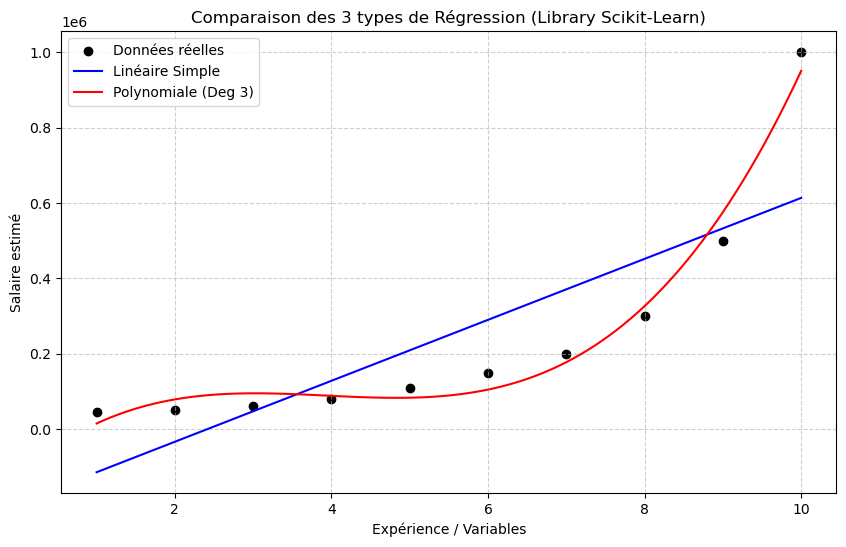

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# =================================================================
# 1. PRÉPARATION DES DONNÉES
# =================================================================
# X_simple : Variable explicative unique (ex: Années d'expérience)
X_simple = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)

# X_multiple : Deux variables explicatives (ex: Expérience ET Niveau d'étude)
X_multiple = np.array([[1, 1], [2, 1], [3, 2], [4, 2], [5, 3], [6, 3], [7, 4], [8, 4], [9, 5], [10, 5]])

# y : Variable cible (ex: Salaire). On remarque une croissance non-linéaire à la fin.
y = np.array([45000, 50000, 60000, 80000, 110000, 150000, 200000, 300000, 500000, 1000000])

# =================================================================
# 2. RÉGRESSION LINÉAIRE SIMPLE (Modèle : y = ax + b)
# =================================================================
print("--- 1. RÉGRESSION LINÉAIRE SIMPLE ---")
model_simple = LinearRegression()
model_simple.fit(X_simple, y) # Apprentissage du coefficient (pente) et du biais
print(f"Coefficient: {model_simple.coef_[0]:.2f}, Biais: {model_simple.intercept_:.2f}\n")

# =================================================================
# 3. RÉGRESSION LINÉAIRE MULTIPLE (Modèle : y = a1x1 + a2x2 + b)
# =================================================================
print("--- 2. RÉGRESSION LINÉAIRE MULTIPLE ---")
model_mult = LinearRegression()
model_mult.fit(X_multiple, y) # On cherche l'impact de chaque variable sur le salaire
print(f"Coefficients (Exp, Étude): {model_mult.coef_}")
print(f"Biais: {model_mult.intercept_:.2f}\n")

# =================================================================
# 4. RÉGRESSION POLYNOMIALE (Modèle courbe)
# =================================================================
print("--- 3. RÉGRESSION POLYNOMIALE ---")
# On transforme X en [1, X, X², X³] pour modéliser une courbe complexe
poly_features = PolynomialFeatures(degree=3) 
X_poly = poly_features.fit_transform(X_simple)

model_poly = LinearRegression()
model_poly.fit(X_poly, y) # Le modèle apprend sur les données transformées
print(f"Coefficients polynomiaux: {model_poly.coef_}\n")

# =================================================================
# 5. VISUALISATION COMPARATIVE
# =================================================================
plt.figure(figsize=(10, 6))
# Affichage des points réels
plt.scatter(X_simple, y, color='black', label='Données réelles')

# Affichage de la droite (Régression Simple)
plt.plot(X_simple, model_simple.predict(X_simple), color='blue', label='Linéaire Simple')

# Affichage de la courbe (Régression Polynomiale)
# On crée un axe X plus dense (100 points) pour que la courbe soit bien lisse
X_range = np.linspace(1, 10, 100).reshape(-1, 1)
X_range_poly = poly_features.transform(X_range)
plt.plot(X_range, model_poly.predict(X_range_poly), color='red', label='Polynomiale (Deg 3)')

plt.title('Comparaison des 3 types de Régression (Library Scikit-Learn)')
plt.xlabel('Expérience / Variables')
plt.ylabel('Salaire estimé')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6) # Ajout d'une grille pour la lisibilité
plt.show()